# Analysis of Provenance Output

This jupyter notebook includes a detailed analysis of the provenance output of PGProv. The analysis follows the following order.

1. Percentage reduction in witness size across scale factors and datasets
2. Percentage reduction in witness size (fine-grained vs coarse) against query size


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["font.family"] = "DejaVu Serif"

pd.set_option('display.float_format', '{:.0f}'.format)

plt.style.use("default")
plt.rcParams.update({
    "font.size": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

In [22]:
# --------------------------------------------------
# FinBench: Query Name Mappings and Query Groups
# --------------------------------------------------

finbench_query_name = {
    1.3: 'RJ-1', 2.3: 'RJ-2', 3: 'J-1', 4.3: 'RJ-3', 5: 'S-1',
    6: 'S-2', 7.3: 'RJ-4', 8: 'J-2', 9.3: 'R-1', 10: 'MM-1',
    11: 'S-3', 12: 'S-4', 13: 'MM-2', 14: 'MM-3', 15: 'S-5',
    16: 'S-6', 17: 'S-7', 18: 'F-1*', 19: 'SQ-1*', 20: 'SQU-1*'
}

finbench_query_groups = {
    "Simple":       ['S-1', 'S-2', 'S-3', 'S-4', 'S-5', 'S-6', 'S-7', 'J-1', 'J-2'],
    "Intermediate": ['MM-1', 'MM-2', 'MM-3', 'F-1*'],
    "Complex":      ['R-1', 'RJ-1', 'RJ-2', 'RJ-3', 'RJ-4', 'SQ-1*', 'SQU-1*']
}

finbench_query_to_group = {}
for group, queries in finbench_query_groups.items():
    for q in queries:
        finbench_query_to_group[q] = group


# --------------------------------------------------
# SNB-BI: Query Name Mappings and Query Groups
# --------------------------------------------------

snb_query_name = {
    1: 'MM-1', 2: 'MM-2', 3: 'R-1', 4: 'SQU-1', 5: 'MM-3',
    6: 'MM-4', 7: 'J-1', 8: 'MM-5', 9: 'R-2', 10: 'MMJ-1',
    11: 'MMJ-2', 12: 'R-3', 13: 'MM-6', 14: 'MMJ-3', 15: 'SQU-2',
    16: 'MMJ-4', 17: 'S-1', 18: 'J-2', 19: 'J-3', 20: 'F-1*'
}

snb_query_groups = {
    "Simple": ['S-1', 'J-1', 'J-2', 'J-3'],
    "Intermediate": ['MM-1', 'MM-2', 'MM-3',
                     'MM-4', 'MM-5', 'MM-6', 'F-1*'],
    "Complex": ['MMJ-1', 'MMJ-2', 'MMJ-3', 'MMJ-4',
                'R-1', 'R-2', 'R-3', 'SQU-1', 'SQU-2']
}

snb_query_to_group = {}
for group, queries in snb_query_groups.items():
    for q in queries:
        snb_query_to_group[q] = group

In [23]:
# --------------------------------------------------
# Query Size Computation
# --------------------------------------------------
# label_size    : Total number of labels referenced in a query
# property_size : Total number of properties referenced in a query
# query_size    : label_size + property_size
# --------------------------------------------------

# --------------------------------------------------
# FinBench
# --------------------------------------------------

finbench_query_label_size ={
    1.3 :  5,  2.3 : 7,  3.0 : 6,  4.3: 5,  5.0 :5,
    6.0 : 7,  7.3: 6,  8.: 8 ,  9.3: 4, 10.: 5 ,
    11.: 7 ,12.: 1 , 13.: 5 , 14.: 5 , 15. : 3,
    16. : 3, 17.: 5 , 18.: 5 , 19.:5 , 20.: 5

}

finbench_query_property_size ={
    1.3 :  6,  2.3 : 5,  3. : 8,  4.3: 1,  5. :7,
    6. : 5,  7.3: 4,  8.: 8 ,  9.3: 3, 10.: 3 ,
    11.: 4 ,12.: 4 , 13.: 5 , 14.: 4 , 15. : 4,
    16. : 4, 17.: 5 , 18.: 5 , 19.:9 , 20.: 5

}

finbench_query_size = {}

for key in finbench_query_label_size.keys():
    finbench_query_size[key] = finbench_query_label_size[key]+ finbench_query_property_size[key]
    


# --------------------------------------------------
# SNB-BI
# --------------------------------------------------

snb_query_label_size ={
    1 :  1,  2 : 7,  3 : 17,  4: 18,  5 :8,
    6 : 11,  7: 7,  8: 8 ,  9: 5, 10: 14 ,
    11.: 16 ,12.: 5 , 13.: 11 , 14.: 23 , 15. : 20,
    16. : 25, 17.: 8 , 18.: 6 , 19.:4 , 20.: 13

}

snb_query_property_size ={
    1 :  4,  2 : 6,  3. : 6,  4: 7,  5. :2,
    6. : 2,  7: 2,  8.: 3 ,  9: 5, 10.: 5 ,
    11.: 7 ,12.: 3 , 13.: 4 , 14.: 5 , 15. : 7,
    16. : 4, 17.: 3 , 18.: 4 , 19.:3 , 20.: 7

}

snb_query_size = {}

for key in snb_query_label_size.keys():
    snb_query_size[key] = snb_query_label_size[key]+ snb_query_property_size[key]



In [24]:
# --------------------------------------------------
# FinBench 
# --------------------------------------------------

finbench_files = [
    "result/phase_metrics/processed/0521_finbench_0.1.log",
    "result/phase_metrics/processed/0530_finbench_0.3.log",
    "result/phase_metrics/processed/0530_finbench_1.log",
    "result/phase_metrics/processed/0530_finbench_3.log",
    "result/phase_metrics/processed/0524_finbench_10.log"
]

test_finbench = pd.concat(
    (
        pd.read_csv(
            f,
            sep="|",
            dtype={"scale_factor": "float64"},
        )
        for f in finbench_files
    ),
    ignore_index=True
)

/tmp/ipykernel_1192667/190919400.py:18: DtypeWarning: Columns (0: result_value, 1: witness_elements, 2: coarse_elements) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(


In [5]:
snb_files = [
    "result/phase_metrics/processed/0531_snb_1.log",
    "result/phase_metrics/processed/0531_snb_3.log",
    # "result/phase_metrics/processed/0530_snb_3_no_witness.log",
    "result/phase_metrics/processed/0530_snb_10.log"
]

test_snb = pd.concat(
    (
        pd.read_csv(
            f,
            sep="|",
            dtype={"scale_factor": "float64"},
        )
        for f in snb_files
    ),
    ignore_index=True
)

In [25]:
def preprocess_data(raw_data, query_name_mapping, query_size_mapping):
    raw_data["cycle"] = 0

    end_rows = raw_data.loc[raw_data['prov_phase'] == 'witness', raw_data.columns].copy()
    
    end_rows['query_type'] = end_rows['query_type'].replace({
        'prov_result': 'prov',
        'prov_coarse_result': 'prov_coarse'
    })
    
    end_rows["query_name"] = end_rows["query_number"].map(query_name_mapping)
    end_rows["query_size"] = end_rows["query_number"].map(query_size_mapping)
    end_rows["query_label_size"] = end_rows["query_number"].map(finbench_query_label_size)
    end_rows["query_property_size"] = end_rows["query_number"].map(finbench_query_property_size)
    return end_rows

In [26]:
end_rows_finbench = preprocess_data(test_finbench, finbench_query_name, finbench_query_size)
end_rows_snb = preprocess_data(test_snb, snb_query_name, snb_query_size)

In [27]:
keys = [
    "dataset",
    "scale_factor",
    "query_number",
    "query_name",
    "parameter",
    "witnesses_per_result",
    "result_value",
    "coarse_elements"
]

end_rows = pd.concat((end_rows_finbench, end_rows_snb),
                     ignore_index=True)

prov_df = end_rows[(end_rows["query_type"] == "prov") & (end_rows["prov_phase"] == "witness")].copy().drop_duplicates(subset=keys, keep="first")
coarse_df = end_rows[(end_rows["query_type"] == "prov_coarse") &  (end_rows["prov_phase"] == "witness")].copy().drop_duplicates(subset=keys, keep="first")

merged = pd.merge(
    prov_df,
    coarse_df,
    on=keys,
    suffixes=("","_coarse")
)

# merged = pd.merge(
#     int_merged,
#     orig_df,
#     on=[
#         "dataset",
#         "scale_factor",
#         "query_number",
#         "parameter"
#     ],
#     suffixes=("","_orig")
# )

merged["label_diff"] = (
        merged["label_count_coarse"] - merged["label_count"]
)

merged["property_diff"] = (
        merged["property_count_coarse"] - merged["property_count"]
)

merged["lp_total_diff"] = (
        merged["property_diff"] + merged["label_diff"]
)

merged["percentage_reduction"] = (
        (merged["lp_total_diff"] * 100) / (merged["property_count_coarse"] + merged["label_count_coarse"])
)

# merged["percentage_overhead_coarse"] = (
#         ((merged["total_execution_time"] - merged["total_execution_time_coarse"]) * 100) / (merged["total_execution_time_coarse"])
# )

# merged["percentage_overhead"] = (
#         ((merged["total_execution_time"] - merged["total_execution_time_orig"]) * 100) / (merged["total_execution_time_orig"])
# )


### Percentage Reduction in Witness Size across Scale Factors and Datasets

In [57]:
dataset_stats = merged.groupby([
    "dataset",
    "scale_factor",
]).agg({
    "percentage_reduction": "mean",
    # "label_diff": "mean",
    # "property_diff": "mean",
    # "lp_total_diff": "mean"
}
).reset_index()

#Load preprocessed and saved large dataset stats
snb_3_dataset_stats = pd.read_csv("result/phase_metrics/snb_3_dataset_summary.csv")
snb_10_dataset_stats = pd.read_csv("result/phase_metrics/snb_10_dataset_summary.csv")

dataset_stats = pd.concat([dataset_stats, snb_3_dataset_stats[["dataset","scale_factor", "percentage_reduction"]]]).reset_index(drop=True)
dataset_stats = pd.concat([dataset_stats, snb_3_dataset_stats[["dataset","scale_factor", "percentage_reduction"]]]).reset_index(drop=True)

dataset_stats

,dataset,scale_factor,percentage_reduction
0,finbench,0.1,81
1,finbench,0.3,87
2,finbench,1,82
3,finbench,3,86
4,finbench,10,81
5,snb,1,82
6,snb,3,86
7,snb,10,81


### Percentage Reduction in Witness Size (Fine-grained vs Coarse) against Query Size

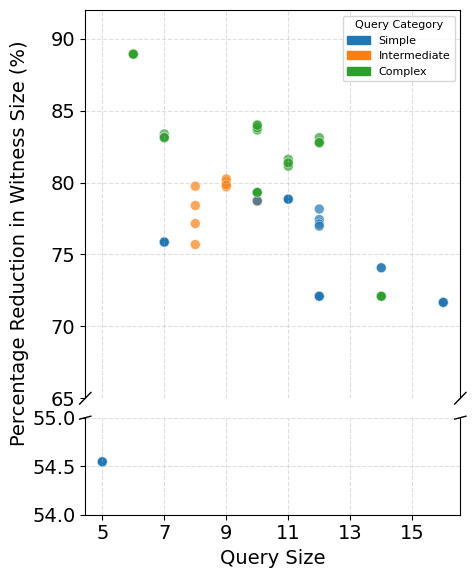

In [292]:
query_level_stats = merged.groupby([
    "dataset",
    "scale_factor",
    "query_name",
    "query_size"
]).agg({
    "percentage_reduction": "mean",
    "witnesses_per_result":"mean",
    "result_value": "count",
}
).reset_index()

#Load preprocessed and saved large dataset stats
snb_3_query_stats = pd.read_csv("result/phase_metrics/snb_3_query_stats.csv")
snb_10_query_stats = pd.read_csv("result/phase_metrics/snb_10_query_stats.csv")

cols = [
        "dataset",
    "scale_factor",
    "query_name",
    "query_size",
    "percentage_reduction",
    "witnesses_per_result",
    "result_value"
]

query_level_stats = pd.concat([query_level_stats, snb_3_query_stats[cols]]).reset_index(drop=True)
query_level_stats = pd.concat([query_level_stats, snb_10_query_stats[cols]]).reset_index(drop=True)

# Colour palette per group
group_colors = {
    "Simple":       "tab:blue",
    "Intermediate": "tab:orange",
    "Complex":      "tab:green"
}

def get_color(row):
    if row["dataset"] == "finbench":
        query_to_group = finbench_query_to_group
    else:
        query_to_group = snb_query_to_group
    group = query_to_group.get(row["query_name"], None)
    return group_colors.get(group, "red")

colors = query_level_stats.apply(lambda x: get_color(x), axis=1)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(5, 6),
    gridspec_kw={'height_ratios': [2, 0.5]}
)

scatter_kwargs = dict(alpha=0.7, s=50, edgecolors='white', linewidths=0.4)

# Top subplot
ax_top.scatter(
    query_level_stats["query_size"],
    # query_level_stats["percentage_overhead"],
    query_level_stats["percentage_reduction"],
    c=colors,
    **scatter_kwargs
)

# Bottom subplot (outlier region)
ax_bottom.scatter(
    query_level_stats["query_size"],
    query_level_stats["percentage_reduction"],
    c=colors,
    **scatter_kwargs
)

ax_bottom.set_ylim(54, 55)
ax_top.set_ylim(65, 92)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(labelbottom=False, bottom=False)

d = .015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs = dict(transform=ax_bottom.transAxes, color='k', clip_on=False, linewidth=1)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bottom.set_xlabel("Query Size")
ax_top.set_ylabel("Percentage Reduction in Witness Size (%)",labelpad=10)
ax_top.yaxis.set_label_coords(-0.15, 0.4)

ax_top.grid(True, linestyle="--", alpha=0.4)
ax_bottom.grid(True, linestyle="--", alpha=0.4)

xticks = range(
    int(query_level_stats["query_size"].min()),
    int(query_level_stats["query_size"].max()),
    2
)
ax_bottom.set_xticks(list(xticks))

legend_handles = [
    mpatches.Patch(color=color, label=group)
    for group, color in group_colors.items()
]

ax_top.legend(handles=legend_handles, title="Query Category",
              fontsize=8, title_fontsize=8, loc="upper right")

plt.tight_layout()
plt.subplots_adjust(hspace=0.08)
# ax_top.set_title("Percentage Reduction in Witness Size vs. Query Size")
plt.show()

# fig.savefig("result/plots/query_size_vs_reduction.png", dpi=300, bbox_inches="tight")

#### Large SNB-BI result file processing

In [ ]:
## Process SNB-BI 3 & 10 chunk by chunk
def process_large_files(file_path, sf):

    chunksize = 500_000  # tune based on RAM
    
    keys = [
        "dataset",
        "scale_factor",
        "query_number",
        "query_name",
        "parameter",
        "witnesses_per_result",
        "result_value",
        "coarse_elements"
    ]
    
    prov_parts = []
    coarse_parts = []
    
    for chunk in pd.read_csv(file_path, sep="|", chunksize=chunksize):
    
        # keep only witness rows immediately (CRITICAL optimization)
        chunk = chunk[chunk["prov_phase"] == "witness"]
    
        if chunk.empty:
            continue
    
        # cycle column
        chunk["cycle"] = 0
    
        # query type normalization
        chunk["query_type"] = chunk["query_type"].replace({
            "prov_result": "prov",
            "prov_coarse_result": "prov_coarse"
        })
    
        # query_name mapping (vectorized, no duplicates)
        chunk["query_name"] = chunk["query_number"].map(snb_query_name)
    
        # split into prov / coarse
        prov = chunk[chunk["query_type"] == "prov"].copy()
        coarse = chunk[chunk["query_type"] == "prov_coarse"].copy()
    
        if not prov.empty:
            prov_parts.append(prov[keys + ["label_count", "property_count"]])
    
        if not coarse.empty:
            coarse_parts.append(coarse[keys + ["label_count", "property_count"]])
    
    # Combine accumulated chunks
    prov_df = pd.concat(prov_parts, ignore_index=True).drop_duplicates(subset=keys)
    coarse_df = pd.concat(coarse_parts, ignore_index=True).drop_duplicates(subset=keys)
    
    merged_snb= pd.merge(
        prov_df,
        coarse_df,
        on=keys,
        suffixes=("", "_coarse")
    )
    
    merged_snb["label_diff"] = merged_snb["label_count_coarse"] - merged_snb["label_count"]
    
    merged_snb["property_diff"] = merged_snb["property_count_coarse"] - merged_snb["property_count"]
    
    merged_snb["lp_total_diff"] = merged_snb["property_diff"] + merged_snb["label_diff"]
    
    merged_snb["percentage_reduction"] = (
        merged_snb["lp_total_diff"] * 100
        / (merged_snb["property_count_coarse"] + merged_snb["label_count_coarse"])
    )
    
    result_1 = merged_snb.groupby([
        "dataset",
        "scale_factor"
    ]).agg({
        "percentage_reduction": "mean",
        "label_diff": "mean",
        "property_diff": "mean",
        "lp_total_diff": "mean"
        # "witnesses_per_result": "mean",
        # "result_value": "count",
    }).reset_index()
    
    result_1.to_csv(f"result/phase_metrics/snb_{sf}_dataset_stats.csv")
    
    
    result_2 = merged_snb.groupby([
        "dataset",
        "scale_factor",
        "query_name"
    ]).agg({
        "percentage_reduction": "mean",
        "witnesses_per_result": "mean",
        "result_value": "count",
    }).reset_index()

    result_2.to_csv(f"result/phase_metrics/snb_{sf}_query_stats.csv")
    
    # result_3 = merged_snb.groupby([
    #     "dataset",
    #     "scale_factor",
    #     "query_name",
    #     "parameter"
    # ]).agg({
    #     "percentage_reduction": "mean",
    #     "witnesses_per_result": "mean",
    #     "result_value": "count",
    # }).reset_index()

In [ ]:
process_large_files("result/phase_metrics/processed/0530_snb_3.log",3)
process_large_files("result/phase_metrics/processed/0530_snb_10_all.log",10)